# 生成伪实验数据

包含：$I(t)$，$Q(t)$。其中每个样本取200个时间点，训练用50000个样本，测试用10000个样本。

任务：把伪数据做好，输入波形是亚采样，通过两个方波（一高一矮）进行读取

In [46]:
!python -m scripts.gen_data_readout --out data/test_readout.npz --n_train 50000 --n_test 10000

saved: data/test_readout.npz  train=(50000, 200, 2) test=(10000, 200, 2)


# 简单分类

用支持向量机（SVM）对每个样本的平均值：$\langle I(t)\rangle$, $\langle Q(t)\rangle$，直接进行分类。

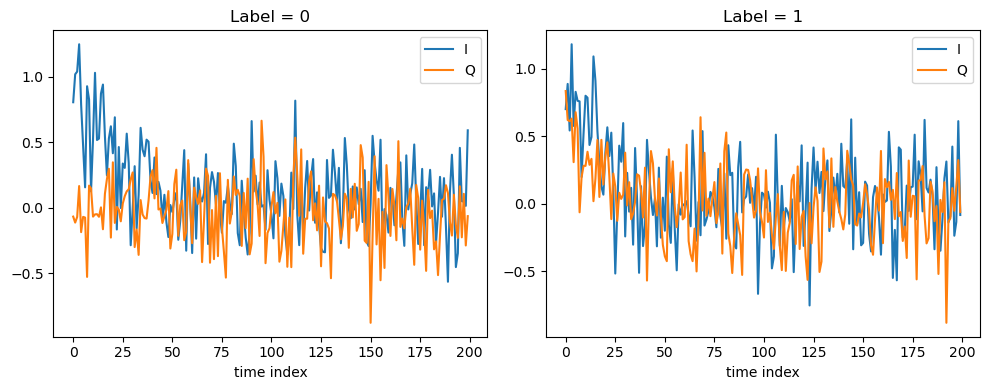

In [47]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load("data/test_readout.npz", allow_pickle=True)
Xtr, y_train, Xte, y_test = d["X_train"], d["y_train"], d["X_test"], d["y_test"]
X_train = np.mean(Xtr, axis=1)
X_test = np.mean(Xte, axis=1)

rng = np.random.default_rng()
idx0 = rng.choice(np.where(y_train == 0)[0])
idx1 = rng.choice(np.where(y_train == 1)[0])

x0, x1 = Xtr[idx0,:,:], Xtr[idx1,:,:]

t = np.arange(x0.shape[0])

plt.figure(figsize=(10,4))

for (i, x) in zip([0,1], [x0,x1]):
    plt.subplot(1,2,i+1)
    plt.plot(t, x[:,0], label='I')
    plt.plot(t, x[:,1], label='Q')
    plt.title(f"Label = {i}")
    plt.xlabel('time index')
    plt.legend()

plt.tight_layout()
plt.show()

The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel
Accuracy: 83.03%


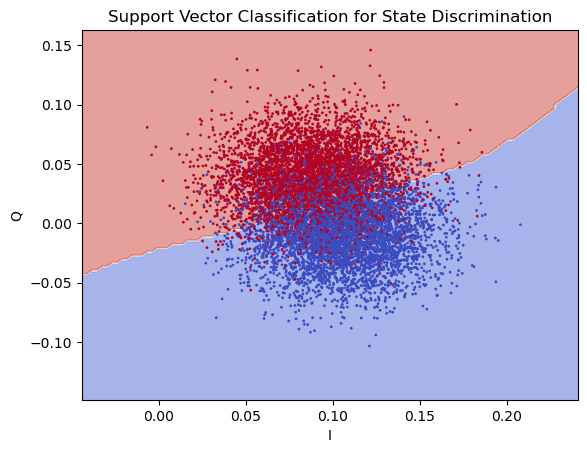

In [48]:
%load_ext cuml.accel
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Create and train the SVM classifier with RBF kernel
classifier = SVC(kernel='rbf', gamma='scale')
classifier.fit(X_train, y_train)

# # Predict and evaluate
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy * 100:.2f}%')

# Plot the decision boundary and IQ points
xx, yy = np.meshgrid(np.linspace(X_train[:, 0].min() - 0.02, X_train[:, 0].max() + 0.02, 100),
                     np.linspace(X_train[:, 1].min() - 0.02, X_train[:, 1].max() + 0.02, 100))
Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.5, cmap='coolwarm')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', s=1)
plt.title('Support Vector Classification for State Discrimination')
plt.xlabel('I')
plt.ylabel('Q')
plt.show()


# 用各种机器学习模型分类

优势在于充分利用了 $I(t)$，$Q(t)$ 中的时间信息。

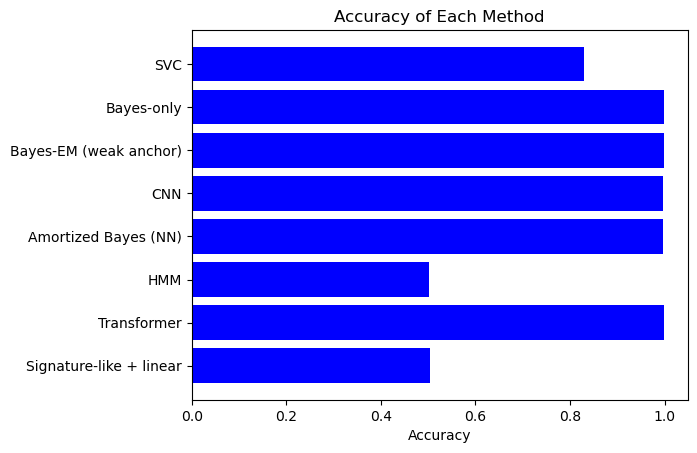

In [56]:
import subprocess
import json
import matplotlib.pyplot as plt

# Run the script and capture output
result = subprocess.run(
    ['python', '-m', 'scripts.run_readout_all', '--in_npz', 'data/test_readout.npz', '--em_iter', '100', '--hmm_iter', '100'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True
)

# Capture the results dictionary from the stdout (if printed by the script)
json_output = result.stdout.split("All Results:")[-1].strip().replace("'", '"')
results = json.loads(json_output)

# Extract accuracies for plotting
methods = ["SVC"] + list(results.keys())
accuracies = [accuracy] + [results[method]["acc"] for method in methods[1:]]

# Plot the accuracies as a bar chart
plt.figure()
plt.barh(methods[::-1], accuracies[::-1], color="b")
plt.xlabel('Accuracy')
plt.title('Accuracy of Each Method')
# plt.grid(True, axis='x')
plt.show()


In [57]:
!python gen_undersampled_readout_noisy.py

[OK] wrote: undersampled_readout_noisy_2us.npz
     rf shape: (500, 10000), labels: [263, 237]
     undersampling alias frequency: 1.000 GHz
     tip: lower --snr_db, increase --phase_fast_std_deg/--amp_fast_std/--baseline_std to make it noisier.


(-1e-09, 5.1e-08)

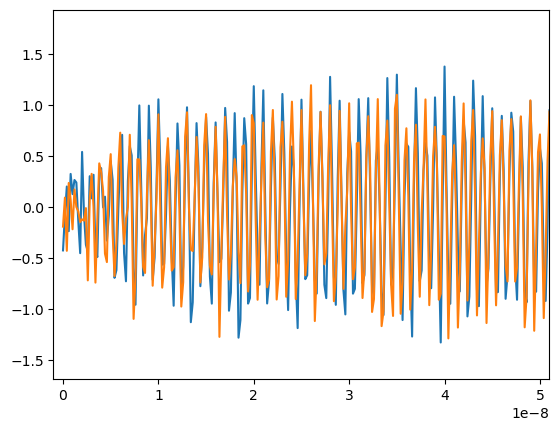

In [79]:
import numpy as np
import json 
import matplotlib.pyplot as plt

data = np.load("undersampled_readout_noisy_2us.npz")

plt.plot(data["t"], data["rf"][3,:])
plt.plot(data["t"], data["rf"][0,:])

plt.xlim(-1e-9, 51e-9)

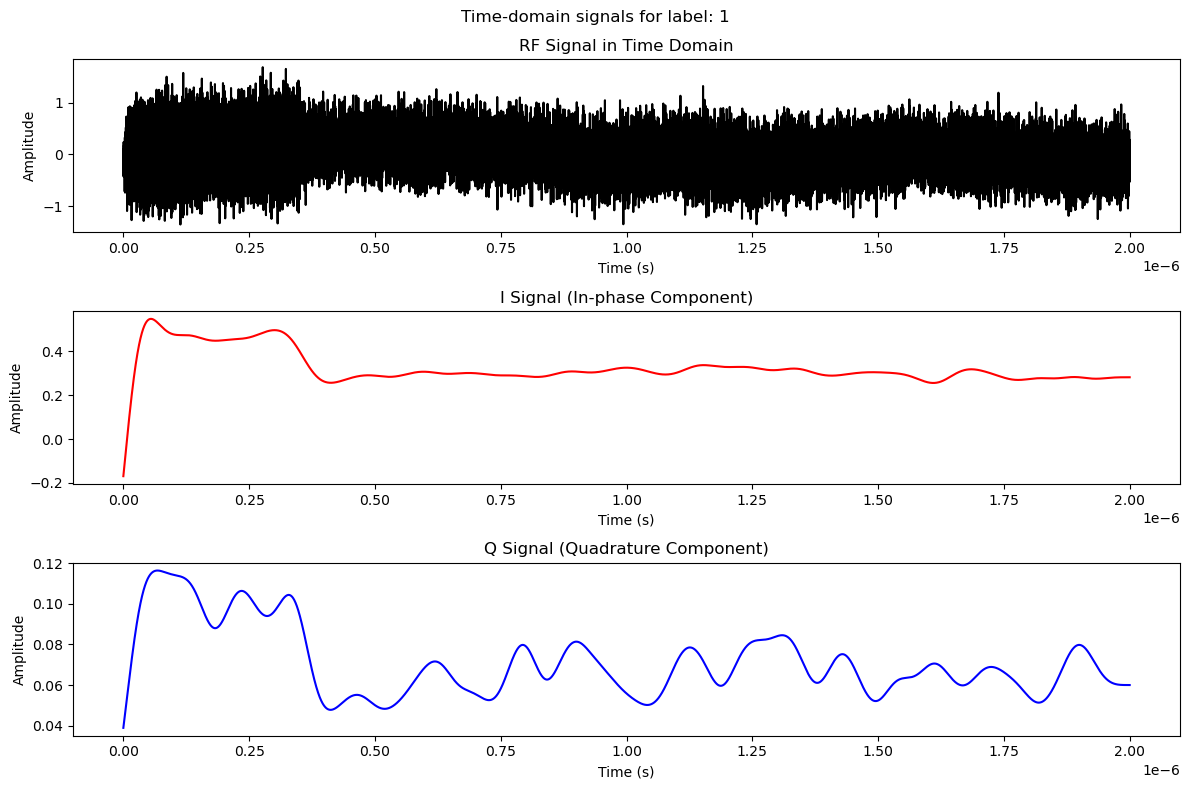

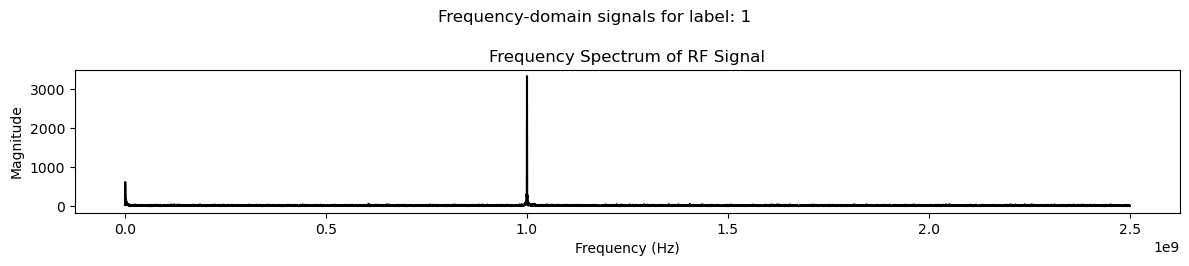

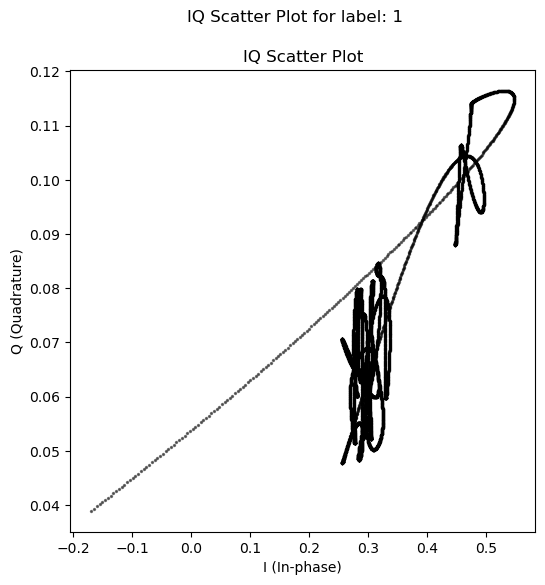

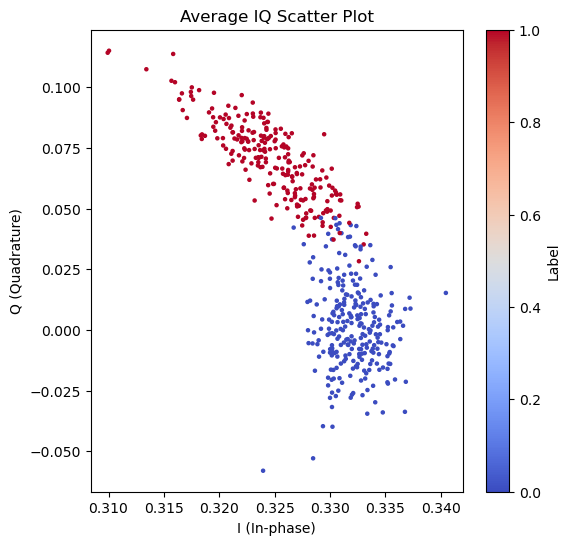

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from cuml.manifold import TSNE as cuTSNE


def lowpass_filter(x, fs, cutoff):
    """Lowpass Butterworth filter"""
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(4, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, x)


def iq_demodulate(rf_signal, fs, f_rf, cutoff):
    """Demodulate the RF signal to IQ signals"""
    # Carrier signal (complex exponential)
    t = np.arange(len(rf_signal)) / fs
    carrier = np.exp(-1j * 2 * np.pi * f_rf * t)
    
    # Multiply with RF signal to downconvert
    baseband_signal = rf_signal * carrier
    
    # Lowpass filter the real and imaginary parts to get I and Q components
    i_signal = lowpass_filter(np.real(baseband_signal), fs, cutoff)
    q_signal = lowpass_filter(np.imag(baseband_signal), fs, cutoff)
    
    return i_signal, q_signal


def plot_time_series(t, rf_signal, i_signal, q_signal, label=None):
    """Plot time-domain signals: RF, I and Q signals"""
    plt.figure(figsize=(12, 8))

    plt.subplot(3, 1, 1)
    plt.plot(t, rf_signal, label="RF Signal", color='black')
    plt.title("RF Signal in Time Domain")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    
    plt.subplot(3, 1, 2)
    plt.plot(t, i_signal, label="I Signal", color='red')
    plt.title("I Signal (In-phase Component)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    
    plt.subplot(3, 1, 3)
    plt.plot(t, q_signal, label="Q Signal", color='blue')
    plt.title("Q Signal (Quadrature Component)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    if label is not None:
        plt.suptitle(f"Time-domain signals for label: {label}")
    plt.tight_layout()
    plt.show()


def plot_frequency_spectrum(rf_signal, i_signal, q_signal, fs, label=None):
    """Plot frequency-domain signals: RF signal and IQ components"""
    N = len(rf_signal)
    freqs = np.fft.fftfreq(N, 1 / fs)
    rf_freq = np.fft.fft(rf_signal)
    i_freq = np.fft.fft(i_signal)
    q_freq = np.fft.fft(q_signal)

    plt.figure(figsize=(12, 8/3))

    # plt.subplot(3, 1, 1)
    plt.plot(freqs[:N // 2], np.abs(rf_freq)[:N // 2], label="RF Signal", color='black')
    plt.title("Frequency Spectrum of RF Signal")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")

    # plt.subplot(3, 1, 2)
    # plt.plot(freqs[:N // 2], np.abs(i_freq)[:N // 2], label="I Signal", color='red')
    # plt.title("Frequency Spectrum of I Signal")
    # plt.xlabel("Frequency (Hz)")
    # plt.ylabel("Magnitude")

    # plt.subplot(3, 1, 3)
    # plt.plot(freqs[:N // 2], np.abs(q_freq)[:N // 2], label="Q Signal", color='blue')
    # plt.title("Frequency Spectrum of Q Signal")
    # plt.xlabel("Frequency (Hz)")
    # plt.ylabel("Magnitude")

    if label is not None:
        plt.suptitle(f"Frequency-domain signals for label: {label}")
    plt.tight_layout()
    plt.show()


def plot_iq_scatter(i_signal, q_signal, label=None):
    """Plot IQ scatter plot"""
    plt.figure(figsize=(6, 6))
    plt.scatter(i_signal, q_signal, s=2, c='black', alpha=0.5)
    plt.title("IQ Scatter Plot")
    plt.xlabel("I (In-phase)")
    plt.ylabel("Q (Quadrature)")

    if label is not None:
        plt.suptitle(f"IQ Scatter Plot for label: {label}")
    plt.show()


def plot_tsne(i_signal, q_signal, labels):
    """Plot t-SNE of IQ data"""
    iq_data = np.vstack((i_signal, q_signal)).T
    tsne = cuTSNE(n_components=2, perplexity=40, random_state=42)
    iq_tsne = tsne.fit_transform(iq_data)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(iq_tsne[:, 0], iq_tsne[:, 1], c=labels, cmap="viridis", s=5)
    plt.title("t-SNE Visualization of IQ Data")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.colorbar(scatter, label="Label")
    plt.show()


def plot_average_iq_scatter(i_signals, q_signals, labels=None):
    """Plot average IQ scatter plot"""
    # Calculate the mean I and Q for each signal
    i_mean = [np.mean(i_signal) for i_signal in i_signals]
    q_mean = [np.mean(q_signal) for q_signal in q_signals]
    
    # Plot the average IQ points
    plt.figure(figsize=(6, 6))
    if labels is not None:
        plt.scatter(i_mean, q_mean, c=labels, cmap='coolwarm', s=5)
        plt.colorbar(label="Label")
    else:
        plt.scatter(i_mean, q_mean, s=5, c='black', alpha=0.5)
    
    plt.title("Average IQ Scatter Plot")
    plt.xlabel("I (In-phase)")
    plt.ylabel("Q (Quadrature)")
    plt.show()


# -----------------------------
# Main workflow for Notebook
# -----------------------------

# Load your .npz file containing the RF signal and other information
npz_data = np.load('undersampled_readout_noisy_2us.npz')

# Extract relevant data
rf_signals = npz_data['rf']
labels = npz_data['y']
fs = npz_data['fs']
f_rf = npz_data['f_rf']
t = npz_data['t']

# Demodulate RF to IQ
cutoff = 10e6  # Lowpass filter cutoff for IQ demodulation (in Hz)
i_signals = []
q_signals = []

for rf_signal in rf_signals:
    i_signal, q_signal = iq_demodulate(rf_signal, fs, f_rf, cutoff)
    i_signals.append(i_signal)
    q_signals.append(q_signal)

# Plot time-domain signals for the first sample (example: label 0 or 1)
plot_time_series(t, rf_signals[0], i_signals[0], q_signals[0], label=labels[0])

# Plot frequency-domain signals for the first sample
plot_frequency_spectrum(rf_signals[0], i_signals[0], q_signals[0], fs, label=labels[0])

# Plot IQ scatter plot for the first sample
plot_iq_scatter(i_signals[0], q_signals[0], label=labels[0])

# # Plot t-SNE visualization for the entire dataset
# plot_tsne(np.array(i_signals).flatten(), np.array(q_signals).flatten(), labels)

# Plot average IQ scatter plot
plot_average_iq_scatter(i_signals, q_signals, labels)


/home/zhou/miniconda/envs/qai/lib/python3.13/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


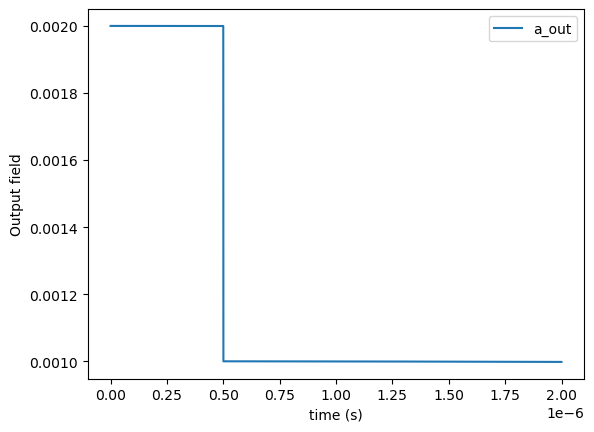

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# ============ 模拟参数 ============
wr = 2*np.pi*5.0e9       # 腔频 5 GHz
wq = 2*np.pi*5.5e9       # qubit 频率
g = 2*np.pi*0.2e9          # dispersive shift
kappa = 2*np.pi*1e6          # 腔泄漏率
gamma_1 = 2*np.pi*1/30e-6             # T1 = 30 us
gamma_phi = 2*np.pi*1/20e-6             # 退相干

# Hilbert 空间
Nc = 10                  # cavity 截止能级
a = tensor(destroy(Nc), qeye(2))

# Pauli
sz = tensor(qeye(Nc), sigmaz())
sp = tensor(qeye(Nc), sigmap())
sm = tensor(qeye(Nc), sigmam())

# ============ 输入脉冲形状：两个方波 ============
def pulse(t, args):
    """两个方波组成的脉冲"""
    # 第一个脉冲：短而高
    pulse1 = np.where((t >= 0) & (t <= 0.5e-6), args['amp1'], 0)
    # 第二个脉冲：长而矮
    pulse2 = np.where((t > 0.5e-6) & (t <= 2e-6), args['amp2'], 0)
    return pulse1 + pulse2

# 旋转坐标下的哈密顿量（去除腔的震荡部分）
H0 = wr * a.dag() * a + wq * sp * sm + g * (a.dag() * sm + a * sp)
H_drive = [a + a.dag(), pulse]  # 驱动项

# ============ 输入‑输出关系 ============
c_ops = [
    np.sqrt(kappa)*a,         # cavity leakage
    np.sqrt(gamma_1)*sm,     # qubit T1
    np.sqrt(gamma_phi)*sz        # qubit dephasing
]

# ============ 演化计算 ============
tlist = np.linspace(0,2e-6, 1000000)
args = {'amp1': 0.002, 'amp2': 0.001}

# 初始状态
ρ0 = tensor(basis(Nc,0), basis(2,0)).proj()

result = mesolve(H0, ρ0, tlist, c_ops, [a.dag()*a, sm], args=args)

n_photon = result.expect[0]
zvals = result.expect[1]

# 输出场：a_out = a_in - sqrt(κ)*<sigma-> + wr 震荡部分
a_in_t = pulse(tlist, args) * np.exp(-1j*wr*tlist)
a_out = a_in_t + np.sqrt(κ)*zvals * np.exp(-1j*wr*tlist)  # 补回 ω_r 震荡

plt.plot(tlist[::100], a_out.real[::100], label="a_out")
plt.xlabel("time (s)")
plt.ylabel("Output field")
plt.legend()
plt.show()


In [62]:
1/30e-6


33333.333333333336

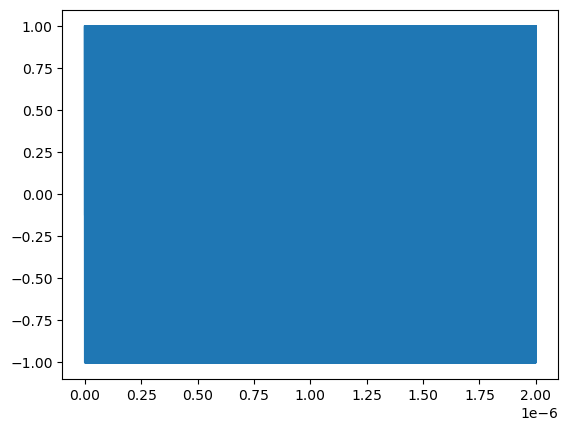

In [51]:
tlist = np.linspace(0,2e-6, 1000000)
plt.plot(tlist, np.exp(-1j*wr*tlist).real)